### Download and Load Zomato Dataset
This dataset is used in the video for Exploratory Data Analysis. It contains two main files: `zomato.csv` and `Country-Code.xlsx`.

In [ ]:
import pandas as pd
import requests
import zipfile
import io

# URL to the dataset hosted on a public GitHub repository (commonly used for this tutorial)
url = 'https://github.com/krishnaik06/5-Days-Live-EDA-and-Feature-Engineering/raw/main/Zomatodataset.zip'

# Download and extract the zip file
response = requests.get(url)
z = zipfile.ZipFile(io.BytesIO(response.content))
z.extractall('/tmp/zomato_data')

# Load the main dataset
# Note: encoding='latin-1' is often required for this specific dataset
df = pd.read_csv('/tmp/zomato_data/zomato.csv', encoding='latin-1')
country_code = pd.read_excel('/tmp/zomato_data/Country-Code.xlsx')

# Merge datasets as shown in the video
final_df = pd.merge(df, country_code, on='Country Code', how='left')

print("Dataset loaded successfully!")
display(final_df.head())

Dataset loaded successfully!


,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes,Country
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Yes,No,No,No,3,4.8,Dark Green,Excellent,314,Phillipines
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Yes,No,No,No,3,4.5,Dark Green,Excellent,591,Phillipines
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Yes,No,No,No,4,4.4,Green,Very Good,270,Phillipines
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,No,No,No,No,4,4.9,Dark Green,Excellent,365,Phillipines
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Yes,No,No,No,4,4.8,Dark Green,Excellent,229,Phillipines


### Initial Data Analysis

In [ ]:
# Display basic info about the DataFrame (data types, non-null counts)
print('DataFrame Info:')
final_df.info()

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9551 entries, 0 to 9550
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Restaurant ID         9551 non-null   int64  
 1   Restaurant Name       9551 non-null   object 
 2   Country Code          9551 non-null   int64  
 3   City                  9551 non-null   object 
 4   Address               9551 non-null   object 
 5   Locality              9551 non-null   object 
 6   Locality Verbose      9551 non-null   object 
 7   Longitude             9551 non-null   float64
 8   Latitude              9551 non-null   float64
 9   Cuisines              9542 non-null   object 
 10  Average Cost for two  9551 non-null   int64  
 11  Currency              9551 non-null   object 
 12  Has Table booking     9551 non-null   object 
 13  Has Online delivery   9551 non-null   object 
 14  Is delivering now     9551 non-null   object 
 15  Switc

In [ ]:
# Display descriptive statistics for numerical columns
print('\nDescriptive Statistics:')
display(final_df.describe())


Descriptive Statistics:


,Restaurant ID,Country Code,Longitude,Latitude,Average Cost for two,Price range,Aggregate rating,Votes
count,9.551000e+03,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000
mean,9.051128e+06,18.365616,64.126574,25.854381,1199.210763,1.804837,2.666370,156.909748
std,8.791521e+06,56.750546,41.467058,11.007935,16121.183073,0.905609,1.516378,430.169145
min,5.300000e+01,1.000000,-157.948486,-41.330428,0.000000,1.000000,0.000000,0.000000
25%,3.019625e+05,1.000000,77.081343,28.478713,250.000000,1.000000,2.500000,5.000000
50%,6.004089e+06,1.000000,77.191964,28.570469,400.000000,2.000000,3.200000,31.000000
75%,1.835229e+07,1.000000,77.282006,28.642758,700.000000,2.000000,3.700000,131.000000
max,1.850065e+07,216.000000,174.832089,55.976980,800000.000000,4.000000,4.900000,10934.000000


In [ ]:
# Check for missing values
print('\nMissing Values per Column:')
display(final_df.isnull().sum())


Missing Values per Column:


,0
Restaurant ID,0
Restaurant Name,0
Country Code,0
City,0
Address,0
Locality,0
Locality Verbose,0
Longitude,0
Latitude,0
Cuisines,9


### Data Preprocessing for ANN
Before feeding the data into a neural network, we must handle categorical variables and scale the features. For this example, we will predict the **Aggregate rating** using features like 'Average Cost for two' and 'Price range'.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Selecting a subset of features for demonstration
features = ['Average Cost for two', 'Price range', 'Votes']
target = 'Aggregate rating'

X = final_df[features]
y = final_df[target]

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scaling features is crucial for ANN convergence
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data preprocessed and ready for ANN.")

Data preprocessed and ready for ANN.


In [ ]:
print(X_test)

      Average Cost for two  Price range  Votes
4731                   350            1     54
1468                   700            2     84
9037                   550            2     36
7866                   200            1    163
5570                   400            1     14
...                    ...          ...    ...
8149                   600            2     44
5849                   400            1      1
9019                   500            2     10
742                   1200            3    334
180                     40            3    428

[1911 rows x 3 columns]


### Define and Train the ANN Model
We will create a simple multi-layer perceptron (MLP) with Dense layers.

In [ ]:
import tensorflow as tf
from tensorflow import keras

class GenericANN:
  def __init__(self,input_shape,hidden_layers,hidden_layer_activation,loss,output_unit,output_activation,metrics=['accuracy'],learning_rate=0.001):
    self.input_shape=input_shape
    self.hidden_layers=hidden_layers
    self.hidden_layer_activation=hidden_layer_activation
    self.loss=loss
    self.output_unit=output_unit
    self.output_activation=output_activation
    self.learning_rate=learning_rate
    self.metrics=metrics
    self.model=self._build_model()

  def _build_model(self):
    model=keras.Sequential()
    model.add(keras.layers.Flatten(input_shape=self.input_shape))

    for unit in self.hidden_layers:
      model.add(keras.layers.Dense(unit,activation=self.hidden_layer_activation))

    model.add(keras.layers.Dense(self.output_unit, activation=self.output_activation))
    optimizer = keras.optimizers.AdaMax(learning_rate = self.learning_rate)

    model.compile(optimizer=optimizer, loss=self.loss, metrics=self.metrics)
    return model

  def summary(self):
    self.model.summary()
  def train(self,x_train,y_train,epochs=10,batch_size=40,validation_split=0.2,verbose=2):
    history =self.model.fit(
        x_train,
        y_train,
        epochs=epochs,
        batch_size=batch_size,
        verbose=verbose,
        validation_split=validation_split
    )
    return history
  def evaluate (self,x_test,y_test,verbose=2):
    loss,accuracy=self.model.evaluate(x_test,y_test,verbose)

  def predict (self,x_new):
    return self.model.predict(x_new)


In [ ]:
myANN=GenericANN(
    input_shape=(3,),
    hidden_layers=[10,20,10],
    hidden_layer_activation='relu',
    loss='mean_squared_error',
    output_unit=1,
    output_activation='linear',
    metrics=['mean_squared_error'],
    learning_rate=0.01
)
myANN.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 3)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │            40 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 20)             │           220 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 10)             │           210 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 481 (1.88 KB)

 Trainable params: 481 (1.88 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history_ann = myANN.train(X_train_scaled,y_train,epochs=30,batch_size=25)

Epoch 1/30
245/245 - 3s - 10ms/step - loss: 0.3277 - mean_squared_error: 0.3277 - val_loss: 0.3205 - val_mean_squared_error: 0.3205
Epoch 2/30
245/245 - 1s - 5ms/step - loss: 0.3424 - mean_squared_error: 0.3424 - val_loss: 0.2542 - val_mean_squared_error: 0.2542
Epoch 3/30
245/245 - 1s - 3ms/step - loss: 0.3035 - mean_squared_error: 0.3035 - val_loss: 0.2249 - val_mean_squared_error: 0.2249
Epoch 4/30
245/245 - 1s - 3ms/step - loss: 0.2918 - mean_squared_error: 0.2918 - val_loss: 0.2838 - val_mean_squared_error: 0.2838
Epoch 5/30
245/245 - 1s - 3ms/step - loss: 0.3439 - mean_squared_error: 0.3439 - val_loss: 0.2158 - val_mean_squared_error: 0.2158
Epoch 6/30
245/245 - 1s - 3ms/step - loss: 0.2890 - mean_squared_error: 0.2890 - val_loss: 0.4582 - val_mean_squared_error: 0.4582
Epoch 7/30
245/245 - 1s - 3ms/step - loss: 0.3176 - mean_squared_error: 0.3176 - val_loss: 0.2428 - val_mean_squared_error: 0.2428
Epoch 8/30
245/245 - 1s - 3ms/step - loss: 0.3365 - mean_squared_error: 0.3365 - v

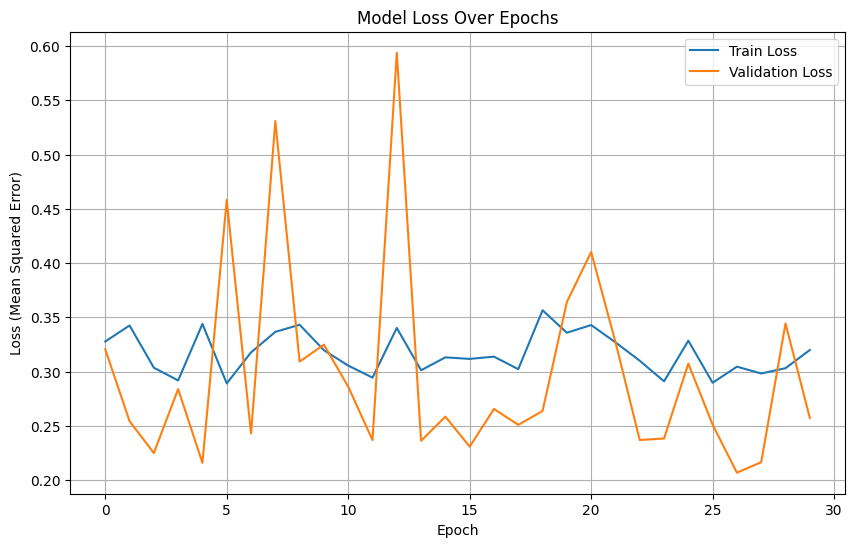

In [ ]:
import matplotlib.pyplot as plt

# Plot training & validation loss values
plt.figure(figsize=(10, 6))
plt.plot(history_ann.history['loss'], label='Train Loss')
plt.plot(history_ann.history['val_loss'], label='Validation Loss')
plt.title('Model Loss Over Epochs')
plt.ylabel('Loss (Mean Squared Error)')
plt.xlabel('Epoch')
plt.legend(loc='upper right')
plt.grid(True)
plt.show()

In [ ]:
myANN.evaluate(X_test_scaled,y_test)

956/956 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.3372 - mean_squared_error: 0.3372


# Neural Network Layer (internal working)

In [ ]:
import numpy as np
from scipy import signal

class ConvolutionalLayer:
  def __init__(self,input_shape,kernel_size,depth):
    input_depth,input_height,input_width=input_shape
    self.depth= depth # kernel depth or the number of nodes
    self.input_shape=input_shape
    self.input_depth=input_depth
    self.output_shape=(depth, input_height-kernel_size+1,input_width-kernel_size+1)
    self.kernels_shape=(depth,input_depth,kernel_size,kernel_size)
    self.kernels= np.random.randn(*self.kernels_shape)
    self.biases= np.random.randn(*self.output_shape)

  def forward(self,input):
    self.input= input
    self.output=np.copy(self.biases)
    for i in range(self.depth):
      for j in range(self.input_depth):
        self.output[i]+=signal.correlate2d(self.input[j],self.kernels[i,j],mode='valid')
    return self.output

  def backward(self, output_gradient,learning_rate):
    kernels_gradient=np.zeros(self.kernels_shape)
    input_gradient=np.zeros(self.input_shape)

    for i in range(self.depth):
      for j in range(self.input_depth):
        kernels_gradient[i,j]=signal.correlate2d(self.input[j],self.output_gradient[i],mode='valid')
        input_gradient[j]+=signal.convolve2d(output_gradient[i],self.kernels[i,j],mode='full')
    self.kernels -= learning_rate * kernels_gradient
    self.biases -= learning_rate * output_gradient # bias_gradient is output_grapdient
    return input_gradient

class ReshapeLayer:
  def __init__(self,input_shape,output_shape):
    self.input_shape=input_shape
    self.output_shape=output_shape
  def forward(self,input):
    return input.reshape(self.output_shape)
  def backward(self,output_gradient):
    return output_gradient.reshape(self.input_shape)

class DenseLayer:
  def __init__(self,input_size,output_size):
    self.weights = np.random.randn(output_size,input_size)*0.01
    self.bias= np.random.randn(output_size,1)

  def forward(self,input):
    self.input=input
    return self.weights@self.input + self.bias

  def backward(self, output_gradient ,learning_rate):
    weights_gradient=output_gradient@self.input.T
    bias_gradient=output_gradient
    bias_gradient=np.sum(output_gradient, axis=1, keepdims=True)
    input_gradient=self.weights.T@output_gradient
    self.weights-=learning_rate*weights_gradient
    self.bias-=learning_rate*bias_gradient
    return input_gradient

class ActivationLayer:
  def __init__(self,activation,activation_prime):
    self.activation=activation
    self.activation_prime=activation_prime
    self.input=None

  def forward(self,input_data):
    self.input=input_data
    return self.activation(self.input)

  def backward(self,output_gradient,learning_rate=0.01):
    return output_gradient*self.activation_prime(self.input)

def relu(x): return np.maximum(0,x)
def relu_prime(x): return (x>0).asType(float)
def loss(y_true, y_pred):
    epsilon = 1e-15
    y_pred = np.clip(y_pred, epsilon, 1 - epsilon)
    return -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))

def loss_prime(y_true, y_pred):
    epsilon = 1e-15
    y_pred = np.clip(y_pred, epsilon, 1 - epsilon)
    return ((1 - y_true) / (1 - y_pred) - y_true / y_pred) / np.size(y_true)

def sigmoid(x):
    x_clipped = np.clip(x, -500, 500)
    return 1 / (1 + np.exp(-x_clipped))

def sigmoid_prime(x):
    s = sigmoid(x)
    return s * (1 - s)



In [ ]:
class Network:
    def __init__(self):
        self.layers = []
        self.loss = None
        self.loss_prime = None

    def add(self, layer):
        """Appends a layer to the network's pipeline."""
        self.layers.append(layer)

    def use(self, loss_function, loss_derivative):
        """Sets the loss function and its derivative for training."""
        self.loss = loss_function
        self.loss_prime = loss_derivative

    def predict(self, input_data):
        """Runs a forward pass for an array of inputs and returns predictions."""
        samples = len(input_data)
        result = []

        # Run each sample through the network
        for i in range(samples):
            output = input_data[i]
            for layer in self.layers:
                output = layer.forward(output)
            result.append(output)

        return result

    def train(self, x_train, y_train, epochs, learning_rate):
        """Trains the network using stochastic gradient descent."""
        samples = len(x_train)

        for epoch in range(epochs):
            display_error = 0
            for j in range(samples):
                # --- 1. Forward Pass ---
                output = x_train[j]
                for layer in self.layers:
                    output = layer.forward(output)

                # Calculate error for display purposes
                display_error += self.loss(y_train[j], output)

                # --- 2. Backward Pass ---
                # Start by taking the derivative of the loss function
                error = self.loss_prime(y_train[j], output)

                # Propagate the error backward through the layers in reverse order
                for layer in reversed(self.layers):
                    error = layer.backward(error, learning_rate)

            # Average error for this epoch
            display_error /= samples
            print(f"Epoch {epoch + 1}/{epochs}   Error: {display_error:.6f}")

# Recurrent Neural Network

In [ ]:
from keras import Sequential
from keras.layers import SimpleRNN,Dense
model = Sequential()
model.add(SimpleRNN(3,input_shape=(4,5)))
model.add(Dense(1,activation='sigmoid'))
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 3)              │            27 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │             4 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31 (124.00 B)

 Trainable params: 31 (124.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
print(model.get_weights()[4].shape)

(1,)


#Demonstartion of RNN (keras)

In [ ]:
doc = [
    "the cat sat on the mat",
    "the dog ran to the park",
    "a bird flew in the sky",
    "the cat chased the bird",
    "the dog barked at the cat",
    "a mat is on the floor"
]

In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import TextVectorization
vectorizer= TextVectorization(max_tokens=10000,output_sequence_length=6)
vectorizer.adapt(doc)

In [ ]:
int_seq = vectorizer(doc)
print(int_seq)

tf.Tensor(
[[ 2  3 11  4  2  5]
 [ 2  6 12  9  2 13]
 [ 8  7 17 15  2 10]
 [ 2  3 18  2  7  0]
 [ 2  6 19 20  2  3]
 [ 8  5 14  4  2 16]], shape=(6, 6), dtype=int64)


In [ ]:
print(vectorizer.get_vocabulary())

['', '[UNK]', np.str_('the'), np.str_('cat'), np.str_('on'), np.str_('mat'), np.str_('dog'), np.str_('bird'), np.str_('a'), np.str_('to'), np.str_('sky'), np.str_('sat'), np.str_('ran'), np.str_('park'), np.str_('is'), np.str_('in'), np.str_('floor'), np.str_('flew'), np.str_('chased'), np.str_('barked'), np.str_('at')]


In [ ]:
from keras.datasets import imdb
from keras import Sequential
from keras.layers import Dense,SimpleRNN,Embedding,Flatten

In [ ]:
(x_train,y_train),(x_test,y_test)= imdb.load_data(num_words=5000)

In [ ]:
from keras.utils import pad_sequences

In [ ]:
x_train= pad_sequences(x_train,padding='post',maxlen=50, dtype='int32')
x_test= pad_sequences(x_test,padding='post',maxlen=50, dtype='int32')

In [ ]:
y_train[1]

np.int64(0)

In [ ]:
from keras.layers import Input

model = Sequential()
model.add(Input(shape=(50,))) # Explicitly define input shape for sequences of length 50
model.add(Embedding(input_dim=5000, output_dim=32))
model.add(SimpleRNN(64, return_sequences=False))
model.add(Dense(1,activation='sigmoid'))
model.summary()

Model: "sequential_18"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_14 (Embedding)        │ (None, 50, 32)         │       160,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_14 (SimpleRNN)       │ (None, 64)             │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 166,273 (649.50 KB)

 Trainable params: 166,273 (649.50 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])
model.fit(x_train,y_train,epochs=5,validation_data=(x_test,y_test))

Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 15s 18ms/step - accuracy: 0.6807 - loss: 0.5673 - val_accuracy: 0.7894 - val_loss: 0.4512
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - accuracy: 0.8295 - loss: 0.3862 - val_accuracy: 0.7986 - val_loss: 0.4449
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - accuracy: 0.8780 - loss: 0.2951 - val_accuracy: 0.7467 - val_loss: 0.5407
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - accuracy: 0.9284 - loss: 0.1870 - val_accuracy: 0.7837 - val_loss: 0.6170
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.9630 - loss: 0.1023 - val_accuracy: 0.7578 - val_loss: 0.7926
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 21s 14ms/step - accuracy: 0.9786 - loss: 0.0632 - val_accuracy: 0.7424 - val_loss: 0.9298
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 12s 16ms/step - accuracy: 0.9826 - loss: 0.0476 - val_accuracy: 0.7665 - val_loss: 1.0303
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - accuracy: 0.9871 - loss: 0.0418 - 

In [ ]:
import numpy as np
class EmbeddingLayer:

  def __init__(self,vocab_size,embedding_dim):
    self.vocab_size=vocab_size
    self.embedding_dim=embedding_dim
    self.weights=np.random.randn(vocab_size,embedding_dim)*0.1
    self.input_indices=None

  def forward(self,input_indices):
   self.input_indices=input_indices
   output_vectors=self.weights[input_indices]
   return output_vectors

  def backward(self,d_out,learning_rate=0.01):
   d_weights=np.zeros_like(self.weights)
   np.add.at(d_weights,self.input_indices,d_out)
   self.weights-=learning_rate*d_weights
   return None

class RNNLayer:

  def __init__(self,input_dim,hidden_dim):
    self.hidden_dim = hidden_dim
    self.w_hx=np.random.randn(input_dim,hidden_dim)*0.1
    self.w_ht=np.random.randn(hidden_dim,hidden_dim)*0.1
    self.bias=np.zeros((1,hidden_dim))

  def forward(self,input):
    self.x=input
    batch_size, sequence_length,input_dim=input.shape ## seq_len: length of the sentence input_dim is the vector from embedded layer
    # memory of RNN
    self.h_t=np.zeros((batch_size,sequence_length+1,self.hidden_dim))
    for t in range(sequence_length):
      x_t=input[:,t,:]
      input_signal= np.dot(x_t,self.w_hx)
      memory_signal=np.dot(self.h_t[:,t,:],self.w_ht)
      self.h_t[:,t+1,:]=np.tanh(input_signal+memory_signal+self.bias)
    return self.h_t[:,-1,:]

  def backward(self,d_h_final,learning_rate=0.01):
    d_w_hx=np.zeros_like(self.w_hx)
    d_w_ht=np.zeros_like(self.w_ht)
    d_bias=np.zeros_like(self.bias)

    batch_size,sequence_length,_=self.x.shape

    d_x=np.zeros_like(self.x)

    d_h_next=d_h_final

    ##BPTT
    for t in reversed(range(sequence_length)):
      h_t=self.h_t[:,t+1,:]
      h_t_prev=self.h_t[:,t,:]
      x_t=self.x[:,t,:]

      d_tannh=d_h_next*(1-h_t**2)

      d_w_ht+=np.dot(h_t_prev.T,d_tannh)
      d_w_hx+=np.dot(x_t.T,d_tannh)
      d_bias+=np.sum(d_tannh,axis=0,keepdims=True)

      d_x[:,t,:]=np.dot(d_tannh,self.w_hx.T)
      d_h_next=np.dot(d_tannh,self.w_ht.T)
    self.w_hx-=learning_rate*d_w_hx
    self.w_ht-=learning_rate*d_w_ht
    self.bias-=learning_rate*d_bias
    return d_x





In [ ]:
class RNNClassifier:
    def __init__(self, vocab_size, embedding_dim, rnn_hidden_dim, num_classes):
        # Initialize the three layers
        self.embedding = EmbeddingLayer(vocab_size, embedding_dim)
        self.rnn = RNNLayer(input_dim=embedding_dim, hidden_dim=rnn_hidden_dim)
        self.dense = DenseLayer(input_size=rnn_hidden_dim, output_size=num_classes)

    def forward(self, X):
        """
        X shape: (batch_size, sequence_length)
        """
        # 1. Embedding Layer
        emb_out = self.embedding.forward(X) # Shape: (batch, seq, emb_dim)

        # 2. RNN Layer
        rnn_out = self.rnn.forward(emb_out) # Shape: (batch, hidden_dim)

        # 3. Transpose for Dense Layer (Dense expects (features, batch))
        dense_in = rnn_out.T                # Shape: (hidden_dim, batch)

        # 4. Dense Layer
        logits = self.dense.forward(dense_in) # Shape: (num_classes, batch)

        # Transpose back to standard (batch, num_classes) for loss calculation
        return logits.T

    def backward(self, d_out, learning_rate=0.01):
        """
        d_out shape: (batch_size, num_classes)
        """
        # 1. Transpose for Dense Layer backward pass
        d_out_T = d_out.T                   # Shape: (num_classes, batch)

        # 2. Dense backward
        d_dense_in = self.dense.backward(d_out_T, learning_rate) # Shape: (hidden_dim, batch)

        # 3. Transpose back for RNN backward pass
        d_rnn_out = d_dense_in.T            # Shape: (batch, hidden_dim)

        # 4. RNN backward
        d_emb_out = self.rnn.backward(d_rnn_out, learning_rate)  # Shape: (batch, seq, emb_dim)

        # 5. Embedding backward
        self.embedding.backward(d_emb_out, learning_rate)

# --- Sample Usage ---

if __name__ == "__main__":
    # Hyperparameters
    VOCAB_SIZE = 1000
    EMB_DIM = 16
    HIDDEN_DIM = 32
    NUM_CLASSES = 2
    BATCH_SIZE = 4
    SEQ_LEN = 5
    LEARNING_RATE = 0.05
    EPOCHS = 15

    # 1. Create the model
    model = RNNClassifier(
        vocab_size=VOCAB_SIZE,
        embedding_dim=EMB_DIM,
        rnn_hidden_dim=HIDDEN_DIM,
        num_classes=NUM_CLASSES
    )

    # 2. Generate dummy data (Batch of 4 sentences, 5 words each)
    # X contains random integer word IDs
    X_train = np.random.randint(0, VOCAB_SIZE, size=(BATCH_SIZE, SEQ_LEN))

    # y contains random targets (binary classification) converted to one-hot encoding
    y_labels = np.random.randint(0, NUM_CLASSES, size=(BATCH_SIZE,))
    y_true = np.zeros((BATCH_SIZE, NUM_CLASSES))
    y_true[np.arange(BATCH_SIZE), y_labels] = 1 # One-hot encode

    print("Training Started...\n")
    for epoch in range(EPOCHS):
        # Forward Pass
        logits = model.forward(X_train)

        # Apply Softmax to get probabilities
        exp_scores = np.exp(logits - np.max(logits, axis=1, keepdims=True))
        probs = exp_scores / np.sum(exp_scores, axis=1, keepdims=True)

        # Calculate Cross-Entropy Loss
        corect_logprobs = -np.log(probs[range(BATCH_SIZE), y_labels])
        loss = np.sum(corect_logprobs) / BATCH_SIZE

        # Backward Pass (Gradient of Cross Entropy + Softmax)
        d_logits = probs.copy()
        d_logits[range(BATCH_SIZE), y_labels] -= 1
        d_logits /= BATCH_SIZE

        # Backpropagate through the whole network
        model.backward(d_logits, learning_rate=LEARNING_RATE)

        print(f"Epoch {epoch+1}/{EPOCHS} | Loss: {loss:.4f}")

Training Started...

Epoch 1/15 | Loss: 0.9228
Epoch 2/15 | Loss: 0.9131
Epoch 3/15 | Loss: 0.9036
Epoch 4/15 | Loss: 0.8945
Epoch 5/15 | Loss: 0.8857
Epoch 6/15 | Loss: 0.8772
Epoch 7/15 | Loss: 0.8689
Epoch 8/15 | Loss: 0.8609
Epoch 9/15 | Loss: 0.8532
Epoch 10/15 | Loss: 0.8457
Epoch 11/15 | Loss: 0.8385
Epoch 12/15 | Loss: 0.8315
Epoch 13/15 | Loss: 0.8247
Epoch 14/15 | Loss: 0.8182
Epoch 15/15 | Loss: 0.8118


##LSTM

In [ ]:
faqs = """About the Program
What is the course fee for  Data Science Mentorship Program (DSMP 2023)
The course follows a monthly subscription model where you have to make monthly payments of Rs 799/month.
What is the total duration of the course?
The total duration of the course is 7 months. So the total course fee becomes 799*7 = Rs 5600(approx.)
What is the syllabus of the mentorship program?
We will be covering the following modules:
Python Fundamentals
Python libraries for Data Science
Data Analysis
SQL for Data Science
Maths for Machine Learning
ML Algorithms
Practical ML
MLOPs
Case studies
You can check the detailed syllabus here - https://learnwith.campusx.in/courses/CampusX-Data-Science-Mentorship-Program-637339afe4b0615a1bbed390
Will Deep Learning and NLP be a part of this program?
No, NLP and Deep Learning both are not a part of this program’s curriculum.
What if I miss a live session? Will I get a recording of the session?
Yes all our sessions are recorded, so even if you miss a session you can go back and watch the recording.
Where can I find the class schedule?
Checkout this google sheet to see month by month time table of the course - https://docs.google.com/spreadsheets/d/16OoTax_A6ORAeCg4emgexhqqPv3noQPYKU7RJ6ArOzk/edit?usp=sharing.
What is the time duration of all the live sessions?
Roughly, all the sessions last 2 hours.
What is the language spoken by the instructor during the sessions?
Hinglish
How will I be informed about the upcoming class?
You will get a mail from our side before every paid session once you become a paid user.
Can I do this course if I am from a non-tech background?
Yes, absolutely.
I am late, can I join the program in the middle?
Absolutely, you can join the program anytime.
If I join/pay in the middle, will I be able to see all the past lectures?
Yes, once you make the payment you will be able to see all the past content in your dashboard.
Where do I have to submit the task?
You don’t have to submit the task. We will provide you with the solutions, you have to self evaluate the task yourself.
Will we do case studies in the program?
Yes.
Where can we contact you?
You can mail us at nitish.campusx@gmail.com
Payment/Registration related questions
Where do we have to make our payments? Your YouTube channel or website?
You have to make all your monthly payments on our website. Here is the link for our website - https://learnwith.campusx.in/
Can we pay the entire amount of Rs 5600 all at once?
Unfortunately no, the program follows a monthly subscription model.
What is the validity of monthly subscription? Suppose if I pay on 15th Jan, then do I have to pay again on 1st Feb or 15th Feb
15th Feb. The validity period is 30 days from the day you make the payment. So essentially you can join anytime you don’t have to wait for a month to end.
What if I don’t like the course after making the payment. What is the refund policy?
You get a 7 days refund period from the day you have made the payment.
I am living outside India and I am not able to make the payment on the website, what should I do?
You have to contact us by sending a mail at nitish.campusx@gmail.com
Post registration queries
Till when can I view the paid videos on the website?
This one is tricky, so read carefully. You can watch the videos till your subscription is valid. Suppose you have purchased subscription on 21st Jan, you will be able to watch all the past paid sessions in the period of 21st Jan to 20th Feb. But after 21st Feb you will have to purchase the subscription again.
But once the course is over and you have paid us Rs 5600(or 7 installments of Rs 799) you will be able to watch the paid sessions till Aug 2024.
Why lifetime validity is not provided?
Because of the low course fee.
Where can I reach out in case of a doubt after the session?
You will have to fill a google form provided in your dashboard and our team will contact you for a 1 on 1 doubt clearance session
If I join the program late, can I still ask past week doubts?
Yes, just select past week doubt in the doubt clearance google form.
I am living outside India and I am not able to make the payment on the website, what should I do?
You have to contact us by sending a mail at nitish.campusx@gmai.com
Certificate and Placement Assistance related queries
What is the criteria to get the certificate?
There are 2 criterias:
You have to pay the entire fee of Rs 5600
You have to attempt all the course assessments.
I am joining late. How can I pay payment of the earlier months?
You will get a link to pay fee of earlier months in your dashboard once you pay for the current month.
I have read that Placement assistance is a part of this program. What comes under Placement assistance?
This is to clarify that Placement assistance does not mean Placement guarantee. So we dont guarantee you any jobs or for that matter even interview calls. So if you are planning to join this course just for placements, I am afraid you will be disappointed. Here is what comes under placement assistance
Portfolio Building sessions
Soft skill sessions
Sessions with industry mentors
Discussion on Job hunting strategies
"""

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer

In [ ]:
tokenizer = Tokenizer()

In [ ]:
tokenizer.fit_on_texts([faqs])

In [ ]:
tokenizer.word_index

{'the': 1,
 'you': 2,
 'i': 3,
 'to': 4,
 'a': 5,
 'of': 6,
 'is': 7,
 'have': 8,
 'will': 9,
 'can': 10,
 'what': 11,
 'course': 12,
 'program': 13,
 'in': 14,
 'for': 15,
 'all': 16,
 'sessions': 17,
 'on': 18,
 'be': 19,
 'and': 20,
 'this': 21,
 'if': 22,
 'am': 23,
 'pay': 24,
 'payment': 25,
 'make': 26,
 'we': 27,
 'do': 28,
 'subscription': 29,
 'where': 30,
 'rs': 31,
 'so': 32,
 'campusx': 33,
 'session': 34,
 'our': 35,
 'paid': 36,
 'join': 37,
 'able': 38,
 'your': 39,
 'website': 40,
 'placement': 41,
 'fee': 42,
 'data': 43,
 'monthly': 44,
 'month': 45,
 'not': 46,
 'get': 47,
 'yes': 48,
 'once': 49,
 'past': 50,
 'feb': 51,
 'assistance': 52,
 'science': 53,
 '7': 54,
 '5600': 55,
 'are': 56,
 'watch': 57,
 'google': 58,
 'by': 59,
 'com': 60,
 'mail': 61,
 'from': 62,
 'contact': 63,
 'us': 64,
 'at': 65,
 'or': 66,
 'doubt': 67,
 'mentorship': 68,
 'payments': 69,
 '799': 70,
 'total': 71,
 'duration': 72,
 'months': 73,
 'learning': 74,
 'case': 75,
 'here': 76,
 '

In [ ]:
input_sequences=[]
for sentence in faqs.split('\n'):
  tokenized_sentence=tokenizer.texts_to_sequences([sentence])[0]

  for i in range(1,len(tokenized_sentence)):
    input_sequences.append(tokenized_sentence[:i+1])

In [ ]:
max_len= max([len(x) for x in input_sequences])

In [ ]:
from tensorflow.keras.preprocessing.sequence import pad_sequences
padded_input_sequences = pad_sequences(input_sequences,maxlen=max_len,padding='pre')

In [ ]:
x = padded_input_sequences[:,:-1]
y= padded_input_sequences[:,-1]

In [ ]:
from tensorflow.keras.utils import to_categorical
y=to_categorical(y,num_classes=283)

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding,LSTM,Dense,Input

In [ ]:
model=Sequential()
model.add(Input(shape=(max_len,))) # Corrected: Use max_len for the input shape
model.add(Embedding(283,100))
model.add(LSTM(150))
model.add(Dense(283,activation='softmax'))

In [ ]:
model.compile(loss='categorical_crossentropy',optimizer='adam',metrics=['accuracy'])

In [ ]:
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ (None, 57, 100)        │        28,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 150)            │       150,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 283)            │        42,733 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 221,633 (865.75 KB)

 Trainable params: 221,633 (865.75 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.fit(x,y,epochs=100)

Epoch 1/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 9s 163ms/step - accuracy: 0.0707 - loss: 5.4352
Epoch 2/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 5s 156ms/step - accuracy: 0.0776 - loss: 5.0857
Epoch 3/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 4s 145ms/step - accuracy: 0.0776 - loss: 5.0091
Epoch 4/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 5s 170ms/step - accuracy: 0.0776 - loss: 4.9627
Epoch 5/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 4s 155ms/step - accuracy: 0.0788 - loss: 4.9040
Epoch 6/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 4s 147ms/step - accuracy: 0.0857 - loss: 4.7988
Epoch 7/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 6s 181ms/step - accuracy: 0.1043 - loss: 4.6332
Epoch 8/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 5s 193ms/step - accuracy: 0.1483 - loss: 4.4307
Epoch 9/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 8s 121ms/step - accuracy: 0.1761 - loss: 4.2199
Epoch 10/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 81ms/step - accuracy: 0.1970 - loss: 4.0046
Epoch 11/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 80ms/step - accuracy: 0.2248 - loss: 3.7916
Epoch 12/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 3s 

In [ ]:
text="mail all our sessions are"
#tokenize
#padd
#send to embed layer
token_text=tokenizer.texts_to_sequences([text])[0]
print (token_text)

[61, 16, 35, 17, 56]


In [ ]:
padded_token_text=pad_sequences([token_text],maxlen=max_len,padding='pre')

In [ ]:
padded_token_text

array([[ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
         0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
         0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
         0,  0,  0,  0, 61, 16, 35, 17, 56]], dtype=int32)

In [ ]:
output= model.predict(padded_token_text)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step


In [ ]:
output.shape

(1, 283)

In [ ]:
import numpy as np
pos=np.argmax(model.predict(padded_token_text))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


In [ ]:
for word,index in tokenizer.word_index.items():
  if index == pos :
    print(word)


recorded


## RAG pipeline test

!pip install -qU langchain langchain-community chromadb sentence-transformers langchain-google-genai

In [ ]:
sample_text = """
Retrieval-Augmented Generation (RAG) is a powerful AI framework.
Instead of relying solely on an LLM's internal memory, RAG searches an external database for facts.
For example, if you ask a RAG system about your company's refund policy, it first searches the company documents, grabs the relevant paragraph, and hands it to the AI.
The AI then reads that paragraph and writes a human-friendly answer.
ChromaDB is a popular open-source vector database used to store these documents.
"""
with open("sample.txt","w") as f:
  f.write(sample_text)
from langchain_community.document_loaders import TextLoader
loader = TextLoader("sample.txt")
documents=loader.load()
print(f"Loaded {len(documents)} documents")

Loaded 1 documents


In [ ]:
documents

[Document(metadata={'source': 'sample.txt'}, page_content="\nRetrieval-Augmented Generation (RAG) is a powerful AI framework.\nInstead of relying solely on an LLM's internal memory, RAG searches an external database for facts.\nFor example, if you ask a RAG system about your company's refund policy, it first searches the company documents, grabs the relevant paragraph, and hands it to the AI.\nThe AI then reads that paragraph and writes a human-friendly answer.\nChromaDB is a popular open-source vector database used to store these documents.\n")]

In [ ]:
!pip install -qU langchain-text-splitters

In [ ]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

In [ ]:
text_splitter= RecursiveCharacterTextSplitter(
    chunk_size=100,
    chunk_overlap=20
)
chunk = text_splitter.split_documents(documents)
print(f"Split the document into {len(chunk)} chunks")
print(f"sample chunk :{chunk[0]}")

Split the document into 6 chunks
sample chunk :page_content='Retrieval-Augmented Generation (RAG) is a powerful AI framework.' metadata={'source': 'sample.txt'}


In [ ]:
from langchain_community.embeddings import HuggingFaceEmbeddings
from langchain_community.vectorstores import Chroma

embeddings = HuggingFaceEmbeddings(model_name="all-MiniLM-L6-v2")
vectorstore = Chroma.from_documents(chunk,embeddings)

/tmp/ipykernel_532/2240813172.py:4: LangChainDeprecationWarning: The class `HuggingFaceEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the `langchain-huggingface package and should be used instead. To use it run `pip install -U `langchain-huggingface` and import as `from `langchain_huggingface import HuggingFaceEmbeddings``.
  embeddings = HuggingFaceEmbeddings(model_name="all-MiniLM-L6-v2")
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [ ]:
retriver = vectorstore.as_retriever(search_kwargs={"k":2})

In [ ]:
retriver.invoke("What is RAG?")

[Document(metadata={'source': 'sample.txt'}, page_content='Retrieval-Augmented Generation (RAG) is a powerful AI framework.'),
 Document(metadata={'source': 'sample.txt'}, page_content="Instead of relying solely on an LLM's internal memory, RAG searches an external database for facts.")]

In [ ]:
# Pull all the data from our vector database
# We specifically ask to include the embeddings, which are hidden by default!
db_data = vectorstore.get(include=['embeddings', 'documents', 'metadatas'])

# Let's grab the very first chunk in the database (index 0)
doc_id = db_data['ids'][0]
metadata = db_data['metadatas'][0]
document = db_data['documents'][0]
embedding = db_data['embeddings'][0]

# Print out the anatomy of the record
print(f"--- RECORD ID: {doc_id} ---")
print(f"Metadata: {metadata}")
print(f"Document Text: '{document}'\n")

# Print the embedding information
print(f"Total Dimensions in this vector: {len(embedding)}")
print(f"Raw Vector Array (Showing the first 10 numbers out of {len(embedding)}):")
print(f"{embedding[:10]} ... [and {len(embedding) - 10} more]")

--- RECORD ID: 45168e40-8c91-4dae-b5c4-c926d83b61b3 ---
Metadata: {'source': 'sample.txt'}
Document Text: 'Retrieval-Augmented Generation (RAG) is a powerful AI framework.'

Total Dimensions in this vector: 384
Raw Vector Array (Showing the first 10 numbers out of 384):
[-0.08849257 -0.02803583 -0.02452126  0.04332009 -0.05221317  0.08923008
  0.02419311 -0.06583181  0.01647482 -0.05797657] ... [and 374 more]


In [ ]:
import os
from google.colab import userdata
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.prompts import ChatPromptTemplate
os.environ["GEMINI_API_KEY"]=userdata.get("GEMINI_API_KEY")

In [ ]:
llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash",temperature=0)
template = """
You are a helpful assistant. Answer the user's question based strictly on the following context.
If the answer is not in the context, say "I don't know based on the provided context."

Context: {context}

Question: {question}

Answer:
"""
prompt = ChatPromptTemplate.from_template(template)

In [ ]:
user_query ="what database is mentioned for storing documents??"

retrived_docs = retriver.invoke(user_query)
context_text="\n\n".join([doc.page_content for doc in retrived_docs])
final_prompt=prompt.format(context=context_text,question=user_query)
raw_response=llm.invoke(final_prompt)
print(raw_response.content)

ChromaDB


In [ ]:
print(retrived_docs)

[Document(metadata={'source': 'sample.txt'}, page_content='ChromaDB is a popular open-source vector database used to store these documents.'), Document(metadata={'source': 'sample.txt'}, page_content="Instead of relying solely on an LLM's internal memory, RAG searches an external database for facts.")]


## Langchain

In [ ]:
!pip install langchian-core langchain-google-genai langchain-huggingface

ERROR: Could not find a version that satisfies the requirement langchian-core (from versions: none)
ERROR: No matching distribution found for langchian-core


In [ ]:
!pip install -r requirement.txt

  Using cached langchain_google_genai-4.2.2-py3-none-any.whl.metadata (2.7 kB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 26.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.2/23.2 MB 38.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.6/67.6 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 515.9/515.9 kB 16.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 43.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 16.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 33.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.1/72.1 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.2/180.2 kB 14.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.0/69.0

In [ ]:
from typing import TypedDict,Annotated,Literal
class Template(TypedDict):
  Usecase: Annotated[str ," a brief summary of use-cases in real life"]
  Comparision: Annotated[str,"in depth comparision of different ideas"]
  Trending: Annotated[Literal["yes","no"],"Is the topic trending software development industry?"]

In [ ]:
!pip install -qU langchain langchain-community  langchain-google-genai

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 113.1/113.1 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 17.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 29.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 542.4/542.4 kB 16.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 173.8/173.8 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.9/64.9 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 1.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.33.1 which is incompatible.


In [ ]:
import os
from google.colab import userdata
from langchain_google_genai import ChatGoogleGenerativeAI
os.environ["GEMINI_API_KEY"]=userdata.get("GEMINI_API_KEY")
llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash",temperature=0)
prompt="give a brief overview of vectorless RAG architecture"
structured_llm = llm.with_structured_output(Template)
response = structured_llm.invoke(prompt)
print(response)

{'Usecase': 'Vectorless RAG architectures are employed when retrieval relies on exact keyword matching, structured queries (e.g., SQL, SPARQL), or graph traversal instead of semantic similarity via vector embeddings. This is beneficial for precise fact retrieval, querying structured databases, or when computational overhead of vector databases is a concern.', 'Comparision': 'Unlike traditional RAG which uses vector embeddings and similarity search (e.g., cosine similarity) to find semantically similar documents, vectorless RAG leverages lexical search (e.g., BM25, TF-IDF), knowledge graphs, or direct database queries for retrieval. It prioritizes explicit matches and structured relationships over dense vector space proximity.', 'Trending': 'yes'}


In [ ]:
from pydantic import BaseModel,Field
from typing import Optional
class Student(BaseModel):
  name : str="student"
  age : Optional[int]=None
  cgpa: float = Field(gt=0, lt=10)


In [ ]:
student= {'name': 'player1','age': 23, 'cgpa':1}
new_student=Student(**student)

In [ ]:
student

{'name': 'player1', 'age': 23, 'cgpa': 1}